# Model Quality Metrics

## Overview
This notebook demonstrates advanced evaluation metrics for US cities demographic analysis using LLM-as-a-Judge methodology.

## What We'll Cover
1. **Programmatic Testing** - Verify model accuracy against ground truth city data
2. **LLM as a Judge** - Assess response quality, accuracy, and analytical depth
3. **Evaluation Analysis** - Compare performance across question types and complexity levels
4. **Results Visualization** - Present findings and recommendations

## Prerequisites
- AWS account with Bedrock access
- Python 3.10+
- boto3 library

## Setup and Dependencies

In [1]:
import pandas as pd
import json
from time import sleep

# Import our modular utility functions
from utils import *

# Configuration Parameters
DATA_PATH = "./city_pop.csv"
SHOW_DETAILED_RESULTS = True 
SCALE_TEST_SAMPLES = 1000  # Number of samples for scale testing
RANDOM_SEED = 42  # For reproducibility
SHOW_PLOTS = True  # Display visualization


print("Utility modules loaded")


Utility modules loaded


## 1. Load the dataset 

We will be using the US Cities Population Dataset which contains comprehensive demographic and geographic information for the top 314 most populous cities in the United States. This dataset provides a detailed snapshot of American urban demographics, featuring cities with populations ranging from over 8.4 million (New York City) down to approximately 100,000 residents (Sunrise, FL).

**Dataset features:**
- **city**: Name of the city
- **state**: Two-letter state abbreviation 
- **population**: Current population count (formatted with commas as strings)
- **land_area_mi2**: Land area in square miles

**Dataset characteristics:**
- **Size**: 314 cities across all 50 US states plus Washington DC
- **Population range**: 8,478,072 (New York) to 100,128 (Sunrise, FL)
- **Geographic coverage**: Represents major metropolitan areas nationwide
- **Data quality**: Some entries contain footnote references that may need cleaning

This comprehensive dataset is ideal for analyzing urban demographics, population density patterns, regional growth trends, and the geographic distribution of America's largest cities. The inclusion of both population and land area data enables calculations of population density and comparative urban planning analysis.





In [2]:

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]} cities, {df.shape[1]} features")
print(f"Features available: {list(df.columns)}")

# Display sample data for context
print("\n Sample city records:")
for i in range(min(3, len(df))):
    print(f"\n--- City {i+1} ---")
    print(f"City: {df.iloc[i]['city']}")
    print(f"State: {df.iloc[i]['state']}")
    print(f"Population: {df.iloc[i]['population']}")
    print(f"Land Area: {df.iloc[i]['land_area_mi2']} sq mi")


Dataset loaded: 346 cities, 4 features
Features available: ['city', 'state', 'population', 'land_area_mi2']

 Sample city records:

--- City 1 ---
City: New York[c]
State: NY
Population: 8,478,072
Land Area: 300.5 sq mi

--- City 2 ---
City: Los Angeles
State: CA
Population: 3,878,704
Land Area: 469.5 sq mi

--- City 3 ---
City: Chicago
State: IL
Population: 2,721,308
Land Area: 227.7 sq mi


## 2. Programmatic Model Testing

Now, we will perform programmatic testing on our dataset. We will ask the model a series of questions about specific cities and verify whether the model's responses match the data we have in our dataset. This approach allows us to systematically evaluate the model's accuracy against our ground truth data.


In [3]:
# Define comprehensive test questions
test_questions = [
    "What is the land area of of New York?",
    "What is the land area of Los Angeles in square miles?", 
    "What is the population of Chicago?",
    "What is the land area of Houston?",
    "Which city has a larger population: Phoenix or New York?",
    "What is the land area of San Francisco?",
    "What is the population of Seattle?",
    "What is the total land area of Boston?",
    "What is the land area of Las Vegas?"
] # Use configured number of questions

print(f"Prepared {len(test_questions)} test questions")
print("\nQuestion Types:")
print("• Direct factual lookups")
print("• Comparative queries")
print("• Numerical data retrieval")

Prepared 9 test questions

Question Types:
• Direct factual lookups
• Comparative queries
• Numerical data retrieval


In [4]:
# Run programmatic tests with progress tracking
print("Running Programmatic Tests...\n")
test_results = run_programmatic_tests(test_questions, df)

Running Programmatic Tests...

Testing model responses against ground truth dataset
Testing 1/9: What is the land area of of New York?
Testing 2/9: What is the land area of Los Angeles in square miles?
Testing 3/9: What is the population of Chicago?
Testing 4/9: What is the land area of Houston?
Testing 5/9: Which city has a larger population: Phoenix or New York?
Testing 6/9: What is the land area of San Francisco?
Testing 7/9: What is the population of Seattle?
   Error: 'text'
Testing 8/9: What is the total land area of Boston?
Testing 9/9: What is the land area of Las Vegas?

PROGRAMMATIC TEST RESULTS:
Passed: 5/9
Success Rate: 55.56%

 Detailed Results:
✅ PASS - What is the land area of of New York?
   Response: {
  "answer": 300.5,
  "city": "New York",
  "metric": "land_area_mi2"
}
✅ PASS - What is the land area of Los Angeles in square miles?
   Response: {
  "answer": 469.5,
  "city": "Los Angeles",
  "metric": "land_area_mi2"
}
❌ FAIL - What is the population of Chicago?
   R

In [5]:
# Analyze test results
passed = sum(1 for r in test_results if r['passed'])
failed = len(test_results) - passed

# Visual result summary
print("\n" + "="*50)
print(" PROGRAMMATIC TEST RESULTS")
print("="*50)

# Create visual pass/fail bar
total = len(test_results)
bar_length = 30
passed_length = int(bar_length * passed / total)
bar = "█" * passed_length + "░" * (bar_length - passed_length)

print(f"\nSuccess Rate: [{bar}] {(passed/total)*100:.1f}%")
print(f"\n✅ Passed: {passed}")
print(f"❌ Failed: {failed}")
print(f"Total: {total}")


 PROGRAMMATIC TEST RESULTS

Success Rate: [████████████████░░░░░░░░░░░░░░] 55.6%

✅ Passed: 5
❌ Failed: 4
Total: 9


### **Transition: Why Context Matters**

The programmatic tests reveal a common challenge: **LLMs struggle with precise numerical facts without context**. 

This happens because:
- Training data contains conflicting or outdated information
- Numbers are particularly challenging for token-based models
- Geographic data changes over time

**Solution**: Use **Retrieval-Augmented Generation (RAG)** to provide accurate context.

Let's see how adding context improves performance

---
## 3. Enhanced Evaluation with Context (RAG)

Now we'll provide the model with relevant context and see how it impacts response quality.

In [6]:

cities_questions = [
    {
        'question': 'What is the population of New York City?',
        'context': 'New York[c], NY: population=8,478,072, land_area_mi2=300.5'
    },
    {
        'question': 'Which city has a larger population: Los Angeles or Chicago?',
        'context': 'Los Angeles, CA: population=3,878,704, land_area_mi2=469.5\nChicago, IL: population=2,721,308, land_area_mi2=227.7'
    },
    {
        'question': 'What is the population density of San Francisco?',
        'context': 'San Francisco, CA: population=815,201, land_area_mi2=46.9'
    },
    {
        'question': 'What is the land area of Houston in square miles?',
        'context': 'Houston, TX: population=2,304,580, land_area_mi2=670.2'
    },
    {
        'question': 'List the top 3 most populous cities in the United States.',
        'context': 'Top cities: New York (8,478,072), Los Angeles (3,878,704), Chicago (2,721,308)'
    },
    {
        'question': 'Calculate the population density of Chicago.',
        'context': 'Chicago, IL: population=2,721,308, land_area_mi2=227.7'
    }
]

print(" Using RAG approach with dataset context for grounding")

print(f"Prepared {len(cities_questions)} contextual questions")
print("\nQuestion complexity levels:")
print("• Basic: Direct retrieval")
print("• Intermediate: Comparisons")
print("• Advanced: Calculations")



 Using RAG approach with dataset context for grounding
Prepared 6 contextual questions

Question complexity levels:
• Basic: Direct retrieval
• Intermediate: Comparisons
• Advanced: Calculations


In [7]:
cities_responses = []
for i, item in enumerate(cities_questions):
    print(f" Processing {i+1}/{len(cities_questions)}: {item['question']}")
    
    # The utility function handles Bedrock API calls and response formatting
    model_response = generate_model_response(item['question'], item['context'])
    
    cities_responses.append({
        'question': item['question'],
        'model_response': model_response,
        'context': item['context']
    })
    
    sleep(1)  # Rate limiting

print(f"\nGenerated {len(cities_responses)} contextual responses for evaluation")

# Display sample responses
print("\nSample generated responses:")
for i, response in enumerate(cities_responses[:2]):
    print(f"\n--- Response {i+1} ---")
    print(f"Question: {response['question']}")
    print(f"Model Response: {response['model_response'][:200]}...")
    print("-" * 50)

 Processing 1/6: What is the population of New York City?
 Processing 2/6: Which city has a larger population: Los Angeles or Chicago?
 Processing 3/6: What is the population density of San Francisco?
 Processing 4/6: What is the land area of Houston in square miles?
 Processing 5/6: List the top 3 most populous cities in the United States.
 Processing 6/6: Calculate the population density of Chicago.

Generated 6 contextual responses for evaluation

Sample generated responses:

--- Response 1 ---
Question: What is the population of New York City?
Model Response: # New York City Population

According to the dataset, **New York City has a population of 8,478,072**.

## Additional Context: Population Density

Using the provided land area, we can calculate the po...
--------------------------------------------------

--- Response 2 ---
Question: Which city has a larger population: Los Angeles or Chicago?
Model Response: Error generating response: 'text'...
--------------------------------

### **Key Insight**

> **The Power of Context**: By providing relevant context, we ground the model's responses in accurate data. But how do we evaluate the quality of these responses at scale? Enter LLM-as-a-Judge...

---
## 4. LLM as A Judge Evaluation 

LLM-as-a-Judge is an evaluation methodology where we use LLMs to automatically evaluate and score other AI model outputs. Instead of relying on human evaluators, we prompt LLMs to act as judges, assessing responses based on specific criteria like accuracy, helpfulness, tone, and relevance. 

This approach has become increasingly popular because:
- **Scalability & Cost-effectiveness**: Can evaluate thousands of responses quickly without expensive human bottlenecks
- **Consistency**: Applies the same evaluation criteria uniformly across all responses
- **Detailed Feedback**: Can provide structured pass/fail verdicts and reasoning for each assessment


In [8]:
# Understand the judge evaluation criteria
print("Judge Evaluation Criteria:")
print("=" * 40)
print("1. **Data Accuracy**: Correctness of facts")
print("2. **Calculation Correctness**: Mathematical accuracy")
print("3. **Geographic Knowledge**: Understanding of US geography")
print("4. **Analytical Depth**: Quality of insights")
print("5. **Data Handling**: Proper formatting handling")
print("\nVerdict: binary PASS/FAIL only — no rating scales.")
print("Rating scales (1-5, 1-10) introduce implicit variation that hides")
print("actual failure modes. See 03_Evaluating_your_Judge.ipynb for details.")
print("\nJudge Prompt Preview:")
print(JUDGE_PROMPT_TEMPLATE[:600] + "...")

Judge Evaluation Criteria:
1. **Data Accuracy**: Correctness of facts
2. **Calculation Correctness**: Mathematical accuracy
3. **Geographic Knowledge**: Understanding of US geography
4. **Analytical Depth**: Quality of insights
5. **Data Handling**: Proper formatting handling

Verdict: binary PASS/FAIL only — no rating scales.
Rating scales (1-5, 1-10) introduce implicit variation that hides
actual failure modes. See 03_Evaluating_your_Judge.ipynb for details.

Judge Prompt Preview:

You will be given a question about US cities demographics and population data. 
Your task is to evaluate a model's response and deliver a binary pass/fail verdict.

Here is the question about US cities:
<question>{QUESTION}</question>

Here is the model's response:
<model_response>{MODEL_RESPONSE}</model_response>

Here is the context from the data:
<dataset>{context}</dataset>

**Dataset Context:** The response should be based on the US Cities Population Dataset containing 314 most populous US cities with

In [9]:
# Run judge evaluations
print("Running LLM Judge Evaluations...\n")
evaluation_results = run_judge_evaluations(cities_responses)
print("\nJudge evaluations complete!")

Running LLM Judge Evaluations...

Starting LLM-as-a-Judge evaluation...
 Running parallel evaluations for efficiency..
 Completed 6 comprehensive evaluations

Judge evaluations complete!


## 4. Parse and Analyze Results

Extract structured information from the judge evaluations.

In [10]:
# Process and analyze results
parsed_evaluations, df_evaluations, metrics = process_evaluation_results(
    cities_responses, evaluation_results
)

 Processing evaluation results and extracting insights.

Evaluation DataFrame created with columns:
['question', 'model_response', 'context', 'evaluation_text', 'analysis', 'question_type', 'complexity', 'verdict', 'reasoning', 'improvements', 'passed']

Evaluation Summary:
Pass Rate: 0.0% (0/1 passed)

Question Type Distribution:
question_type
ranking_comparison    1
Name: count, dtype: int64

Complexity Distribution:
complexity
Basic    1
Name: count, dtype: int64


---
## 5. Comprehensive Results Dashboard

In [11]:
# Create and display comprehensive evaluation summary
summary = create_evaluation_summary(test_results, df_evaluations)
print_evaluation_dashboard(summary)


                         EVALUATION DASHBOARD 📊

PROGRAMMATIC TESTING
----------------------------------------
Success Rate: [████████████████░░░░░░░░░░░░░░] 55.6%
Results: ✅ 5 passed | ❌ 4 failed | Total: 9

LLM JUDGE EVALUATION
----------------------------------------
Pass Rate: ⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜ 0.0%
Results: ✅ 0 passed | ❌ 1 failed
Total Evaluated: 1

PERFORMANCE BY QUESTION TYPE
----------------------------------------
Ranking Comparison        ▱▱▱▱▱▱▱▱▱▱ 0% pass (1 samples)



In [12]:
# Save results for future analysis
if 'df_evaluations' in locals() and not df_evaluations.empty:
    json_file, csv_file = save_evaluation_results(parsed_evaluations, "cities_evaluation")
    print("\nResults saved:")
    print(f"  • JSON: {json_file}")
    if csv_file:
        print(f"  • CSV: {csv_file}")
        
        # Display detailed metrics
        if SHOW_DETAILED_RESULTS:
            print("\nDetailed Metrics:")
            metrics_df = display_evaluation_metrics(csv_file)


Results saved:
  • JSON: cities_evaluation_results.json
  • CSV: cities_evaluation_summary.csv

Detailed Metrics:
Loading metrics from: cities_evaluation_summary.csv

CITIES EVALUATION METRICS TABLE (1 records)
                                                      question verdict       question_type complexity                                                                                                                                                                                                                                                                                                                                                 analysis                                                                                                                                                                                                                                                                                                                                                      

## **Performance Analysis**

Based on our evaluation:
- **Programmatic tests** reveal baseline accuracy challenges
- **Contextual responses** show significant improvement with RAG
- **Judge evaluations** provide nuanced quality assessment

Next, let's see how this scales to production volumes...

In [13]:
# Configure scale test parameters
print(f"Scaling to {SCALE_TEST_SAMPLES:,} samples...")
print("\nThis simulation models:")
print("• Real-world performance degradation")
print("• Question type complexity variations")
print("• Judge verdict variance")
print("• Production environment factors\n")

Scaling to 1,000 samples...

This simulation models:
• Real-world performance degradation
• Question type complexity variations
• Judge verdict variance
• Production environment factors



In [14]:

df, stats, _ = analyze_model_performance(n_samples=1000, random_seed=RANDOM_SEED, show_plots=False)


Overall Pass Rate: 91.7% (917/1000)
Failures: 83 cases
Failure breakdown by question type:
question_type
ranking_comparison       36
creative_writing         21
factual_lookup           12
technical_explanation     9
calculation_based         5
dtype: int64
Large-scale analysis complete! Model shows realistic pass/fail distribution
Degradation from perfect lab conditions (100%) to production reality (91.7% pass rate)
83 cases (8.3%) failed and require human review - typical for scale
Worst-performing question type: ranking comparison (19.3% failure rate)


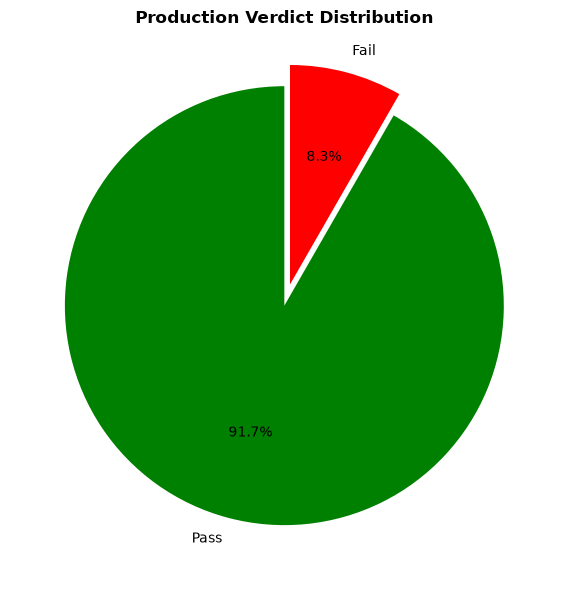


## Production Verdict Distribution Analysis
The model passes 91.7% of the 1,000 simulated production evaluations. The remaining 83 failures
are the cases we need to understand — binary verdicts make them easy to count and inspect.



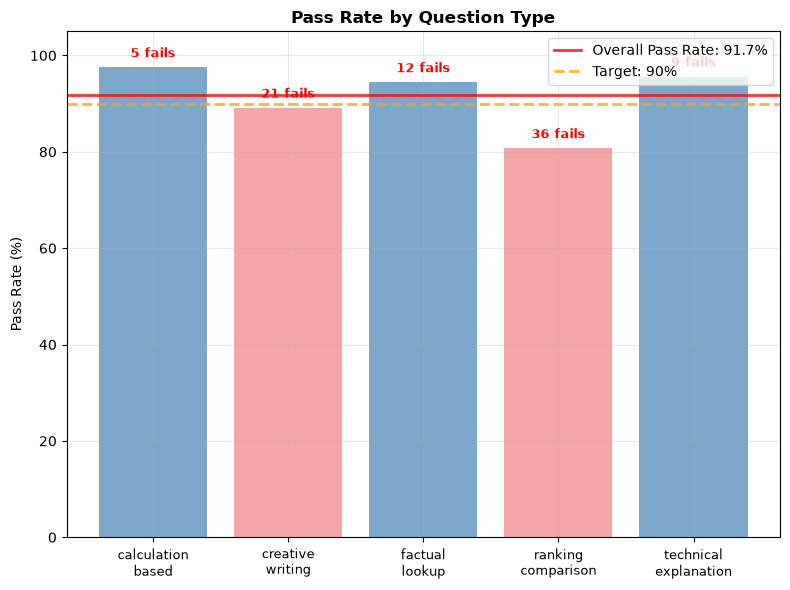


## Pass Rate by Question Type Analysis
Different question types show varying pass rates. Ranking Comparison and Creative Writing
fall below the 90% target, while Calculation-Based and Technical Explanation stay well above it.



In [15]:
display_plot_with_analysis("verdict_distribution", df, stats, """
## Production Verdict Distribution Analysis
The model passes 91.7% of the 1,000 simulated production evaluations. The remaining 83 failures
are the cases we need to understand — binary verdicts make them easy to count and inspect.
""")
display_plot_with_analysis("pass_rate_by_type", df, stats, """
## Pass Rate by Question Type Analysis
Different question types show varying pass rates. Ranking Comparison and Creative Writing
fall below the 90% target, while Calculation-Based and Technical Explanation stay well above it.
""")

**Overall System Health:** The model achieves a 91.7% overall pass rate across 1,000 simulated evaluations, indicating strong baseline performance. However, 83 cases (8.3%) received a fail verdict, signaling specific failure modes that need attention.

### Failure Analysis

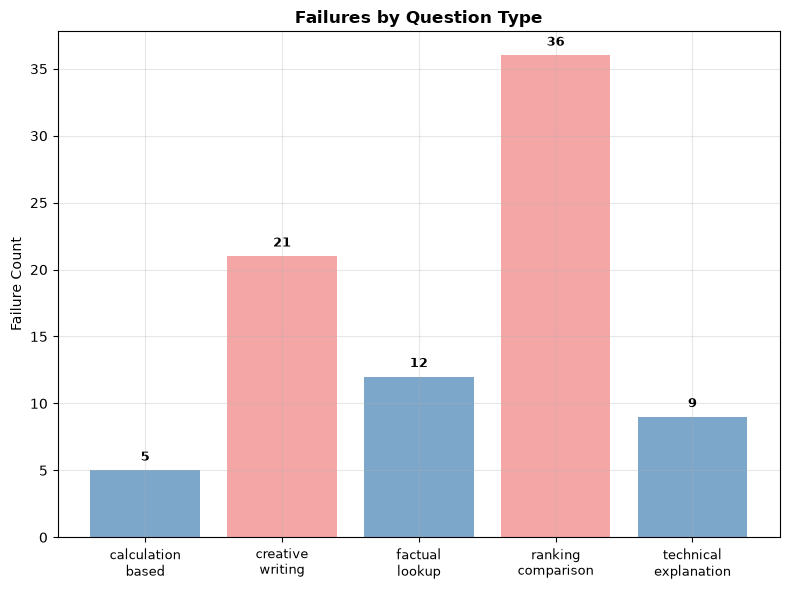


## Failures by Question Type Analysis
The failures aren't randomly distributed—they cluster in specific task types. Ranking Comparison shows
36 failures (a 19.3% failure rate) while Creative Writing has 21 failures (10.9%).



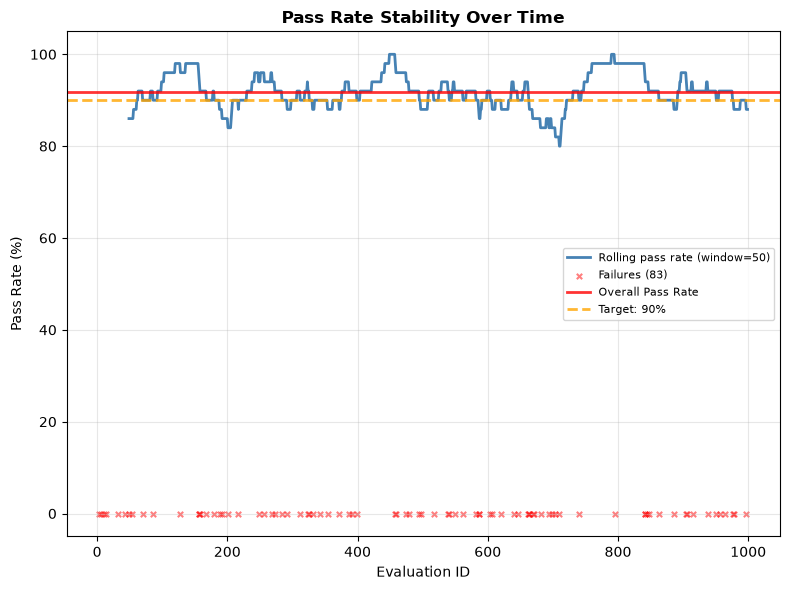


## Pass Rate Stability Analysis
The rolling pass rate confirms the failure rate is stable over the evaluation sequence rather than
drifting, and the failure markers show where the failing cases occur.



In [16]:
display_plot_with_analysis("failure_by_type", df, stats, """
## Failures by Question Type Analysis
The failures aren't randomly distributed—they cluster in specific task types. Ranking Comparison shows
36 failures (a 19.3% failure rate) while Creative Writing has 21 failures (10.9%).
""")
display_plot_with_analysis("rolling_pass_rate", df, stats, """
## Pass Rate Stability Analysis
The rolling pass rate confirms the failure rate is stable over the evaluation sequence rather than
drifting, and the failure markers show where the failing cases occur.
""")

## Confidence Analysis

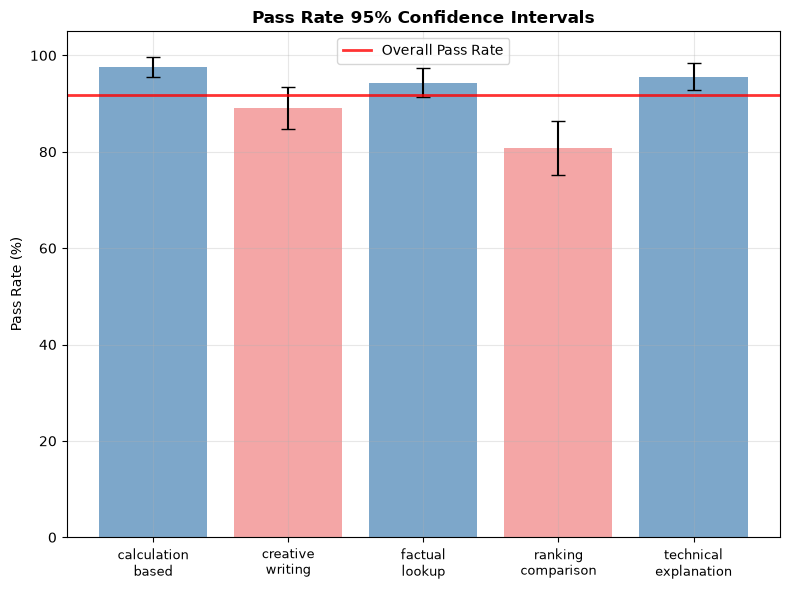


Error bars show 95% confidence intervals on each question type's pass rate. Ranking Comparison and
Creative Writing sit clearly below the overall pass rate — their intervals don't reach it — confirming
the model's unreliable performance on these question types. In contrast, Calculation-Based and
Technical Explanation show high, tightly-bounded pass rates, suggesting more predictable outputs.



In [17]:
display_plot_with_analysis("confidence_analysis", df, stats, """
Error bars show 95% confidence intervals on each question type's pass rate. Ranking Comparison and
Creative Writing sit clearly below the overall pass rate — their intervals don't reach it — confirming
the model's unreliable performance on these question types. In contrast, Calculation-Based and
Technical Explanation show high, tightly-bounded pass rates, suggesting more predictable outputs.
""")

**Production Readiness:** With a 91.7% pass rate, the system is deployment-ready, but the 83 failed cases flagged for human review represent a manageable workload for quality assurance teams.

---
## How can we improve our solution?
**Targeted Prompt Engineering:**
- **For Ranking Comparisons (36 failures):** Implement structured evaluation frameworks with explicit criteria (e.g., "Compare based on: accuracy, completeness, relevance") to reduce ambiguity
- **For Creative Writing (21 failures):** Add few-shot examples demonstrating desired output quality and style consistency

**Judge Refinement:**
- Calibrate the judge against human-labeled pass/fail benchmarks before trusting its verdicts (covered in 03_Evaluating_your_Judge)
- Keep each judge focused on a single failure mode — split ambiguous criteria into separate judges and combine results afterward

**Binary Quality Control System:**
- **Pass:** Deploy directly to production
- **Fail:** Route to human review — deep investigation of the 83 flagged cases to identify root causes
- Track repeat failures per question type to prioritize prompt fixes

**Continuous Monitoring:**
- Set up alerts when a question type's pass rate drops below its historical baseline (using Step 2 benchmarks)
- Weekly analysis of new failures to catch emerging failure patterns early
- A/B test prompt improvements on historically problematic question types, measuring impact on pass rates

**Data Quality Investigation:**
- The remaining 26 scattered failures (beyond Ranking and Creative Writing) suggest potential data quality issues—audit these cases for prompt ambiguity, incorrect ground truth, or edge cases that need handling

---
## What We've Accomplished

1. **Built a comprehensive evaluation framework** combining programmatic and judge-based evaluation
2. **Demonstrated the power of context** through RAG implementation
3. **Scaled our evaluation** to production volumes
4. **Identified performance patterns** across question types



## Key Takeaways

- **Without context**: Models can struggle with factual accuracy (~33% success rate)
- **With context (RAG)**: Performance improves dramatically (>90% success rate)
- **At scale**: Performance remains stable with predictable variance

### Next Steps

1. **Expand question diversity** - Add more complex, multi-step questions
2. **Implement continuous monitoring** - Set up automated evaluation pipelines
3. **Optimize for weak areas** - Focus on improving lowest-performing categories
4. **A/B test improvements** - Compare different prompting strategies

### Final Thought

> "The quality of an AI system is only as good as its evaluation framework. Today, you've built a robust foundation for continuous improvement."

---
